In [ ]:
from google.colab import files
uploaded = files.upload()

Saving comparison.xlsx to comparison (1).xlsx


In [ ]:
import pandas as pd

df = pd.read_excel("comparison.xlsx")

df.head()

,Bond Angle,Bond Distance,Entanglement
0,35.87,0.75,0.308897
1,35.87,0.85,0.247167
2,35.87,0.95,0.217923
3,35.87,1.05,0.232627
4,35.87,1.15,0.222190


In [ ]:
print(df.columns)

Index(['Bond Angle', 'Bond Distance', 'Entanglement'], dtype='object')


In [ ]:
print(df.shape)

df.describe()

(450, 3)


,Bond Angle,Bond Distance,Entanglement
count,450.000000,450.00000,450.000000
mean,108.370000,1.45000,0.138175
std,43.325373,0.43253,0.022789
min,35.870000,0.75000,0.094677
25%,70.870000,1.05000,0.128062
50%,108.370000,1.45000,0.130799
75%,145.870000,1.85000,0.145062
max,180.870000,2.15000,0.308897


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score

# Features and target
X = df[["Bond Angle", "Bond Distance"]]
y = df["Entanglement"]

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

models = {
    "Linear Regression": LinearRegression(),
    "Polynomial Regression": make_pipeline(
        PolynomialFeatures(degree=3),
        LinearRegression()
    ),
    "Random Forest": RandomForestRegressor(
        n_estimators=200,
        random_state=42
    )
}

for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)

    r2 = r2_score(y_test, pred)

    print(f"{name}: R² = {r2:.4f}")

Linear Regression: R² = 0.5692
Polynomial Regression: R² = 0.8943
Random Forest: R² = 0.9221


In [ ]:
from sklearn.ensemble import RandomForestRegressor

best_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

best_model.fit(X_train, y_train)

RandomForestRegressor(n_estimators=200, random_state=42)

In [ ]:
import pandas as pd

def predict_entanglement(angle, distance):

    sample = pd.DataFrame({
        "Bond Angle": [angle],
        "Bond Distance": [distance]
    })

    return best_model.predict(sample)[0]

In [ ]:
def predict_entanglement(angle, distance):
    return best_model.predict([[angle, distance]])[0]

In [ ]:
value = predict_entanglement(104.5, 0.96)

print(value)

0.1469722332599998


In [ ]:
from ipywidgets import interact
import pandas as pd

@interact(
    angle=(35.87,180.87,1),
    distance=(0.75,2.15,0.05)
)
def predictor(angle=104.5, distance=0.96):

    sample = pd.DataFrame({
        "Bond Angle":[angle],
        "Bond Distance":[distance]
    })

    value = best_model.predict(sample)[0]

    print(f"Bond Angle      : {angle:.2f}°")
    print(f"Bond Distance   : {distance:.2f} Å")
    print(f"Entanglement ξ  : {value:.6f}")

interactive(children=(FloatSlider(value=104.5, description='angle', max=180.87, min=35.87, step=1.0), FloatSli…

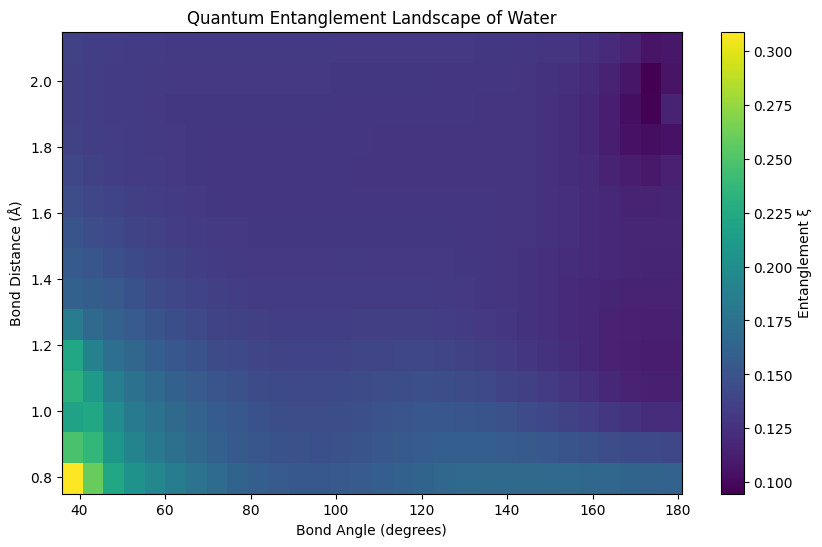

In [ ]:
import matplotlib.pyplot as plt

pivot = df.pivot(
    index="Bond Distance",
    columns="Bond Angle",
    values="Entanglement"
)

plt.figure(figsize=(10,6))

extent = [
    pivot.columns.min(),
    pivot.columns.max(),
    pivot.index.min(),
    pivot.index.max()
]

plt.imshow(
    pivot,
    aspect='auto',
    origin='lower',
    extent=extent
)

plt.colorbar(label='Entanglement ξ')

plt.xlabel("Bond Angle (degrees)")
plt.ylabel("Bond Distance (Å)")
plt.title("Quantum Entanglement Landscape of Water")

plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact

@interact(
    angle=(35.87,180.87,1),
    distance=(0.75,2.15,0.05)
)
def visualize(angle=104.5, distance=0.96):

    theta = np.radians(angle)

    O = np.array([0,0])

    H1 = np.array([distance,0])

    H2 = np.array([
        distance*np.cos(theta),
        distance*np.sin(theta)
    ])

    sample = pd.DataFrame({
        "Bond Angle":[angle],
        "Bond Distance":[distance]
    })

    ent = best_model.predict(sample)[0]

    plt.figure(figsize=(6,6))

    plt.plot([O[0],H1[0]],[O[1],H1[1]],linewidth=3)
    plt.plot([O[0],H2[0]],[O[1],H2[1]],linewidth=3)

    plt.scatter(O[0],O[1],s=400)
    plt.scatter(H1[0],H1[1],s=200)
    plt.scatter(H2[0],H2[1],s=200)

    plt.text(O[0],O[1],"O",fontsize=14)
    plt.text(H1[0],H1[1],"H",fontsize=14)
    plt.text(H2[0],H2[1],"H",fontsize=14)

    plt.title(
        f"Angle={angle:.1f}°   Distance={distance:.2f} Å\n"
        f"Predicted Entanglement ξ={ent:.6f}"
    )

    plt.axis('equal')
    plt.grid(True)

    plt.show()

interactive(children=(FloatSlider(value=104.5, description='angle', max=180.87, min=35.87, step=1.0), FloatSli…

In [ ]:
import joblib

joblib.dump(best_model, "entanglement_model.pkl")

['entanglement_model.pkl']

In [ ]:
from google.colab import files

files.download("entanglement_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>